**This cell imports pandas, numpy and matplotlib, brings in the stress-test helper from src/stress.py, and loads everything I need for stress testing.**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import PROCESSED_DATA_DIR, STRESS_WINDOWS, HYPOTHETICAL_SHOCK
from src.data_utils import read_panel
from src.stress import compute_window_metrics

# Load returns
us = read_panel(PROCESSED_DATA_DIR / "us_portfolio.parquet")["return"]
india = read_panel(PROCESSED_DATA_DIR / "india_portfolio.parquet")["return"]

# Load static VaR
us_static_95 = pd.read_parquet(PROCESSED_DATA_DIR / "us_var_static_95.parquet")
us_static_99 = pd.read_parquet(PROCESSED_DATA_DIR / "us_var_static_99.parquet")
india_static_95 = pd.read_parquet(PROCESSED_DATA_DIR / "india_var_static_95.parquet")
india_static_99 = pd.read_parquet(PROCESSED_DATA_DIR / "india_var_static_99.parquet")

# Load GARCH/GJR
us_garch_95 = pd.read_parquet(PROCESSED_DATA_DIR / "us_garch_var_95.parquet")
us_garch_99 = pd.read_parquet(PROCESSED_DATA_DIR / "us_garch_var_99.parquet")
us_gjr_95 = pd.read_parquet(PROCESSED_DATA_DIR / "us_gjr_var_95.parquet")
us_gjr_99 = pd.read_parquet(PROCESSED_DATA_DIR / "us_gjr_var_99.parquet")
india_garch_95 = pd.read_parquet(PROCESSED_DATA_DIR / "india_garch_var_95.parquet")
india_garch_99 = pd.read_parquet(PROCESSED_DATA_DIR / "india_garch_var_99.parquet")
india_gjr_95 = pd.read_parquet(PROCESSED_DATA_DIR / "india_gjr_var_95.parquet")
india_gjr_99 = pd.read_parquet(PROCESSED_DATA_DIR / "india_gjr_var_99.parquet")

print("Loaded all data.")

Loaded all data.


**This cell organises the 24 VaR series into a nested structure: var_data[market][level][method] returns the right series for any combination. Doing this once up front means the loop in the next step can iterate cleanly over markets, levels and methods without a forest of variable names. I also build a small returns_data dict for the same reason.**

In [2]:
var_data = {
    "US": {
        "95%": {
            "Historical": us_static_95["historical_var"],
            "Normal": us_static_95["normal_var"],
            "Student-t": us_static_95["student_t_var"],
            "Monte_Carlo": us_static_95["monte_carlo_var"],
            "GARCH": us_garch_95["var"],
            "GJR-GARCH": us_gjr_95["var"],
        },
        "99%": {
            "Historical": us_static_99["historical_var"],
            "Normal": us_static_99["normal_var"],
            "Student-t": us_static_99["student_t_var"],
            "Monte_Carlo": us_static_99["monte_carlo_var"],
            "GARCH": us_garch_99["var"],
            "GJR-GARCH": us_gjr_99["var"],
        },
    },
    "India": {
        "95%": {
            "Historical": india_static_95["historical_var"],
            "Normal": india_static_95["normal_var"],
            "Student-t": india_static_95["student_t_var"],
            "Monte_Carlo": india_static_95["monte_carlo_var"],
            "GARCH": india_garch_95["var"],
            "GJR-GARCH": india_gjr_95["var"],
        },
        "99%": {
            "Historical": india_static_99["historical_var"],
            "Normal": india_static_99["normal_var"],
            "Student-t": india_static_99["student_t_var"],
            "Monte_Carlo": india_static_99["monte_carlo_var"],
            "GARCH": india_garch_99["var"],
            "GJR-GARCH": india_gjr_99["var"],
        },
    },
}

returns_data = {"US": us, "India": india}

print("Data structure built.")

Data structure built.


**This cell loops through the three crisis windows (COVID 2020, China 2015, Volmageddon 2018), the relevant markets for each window (As Volmageddon is US-only by design), both confidence levels, and all six methods.** 

**For each combination it slices both the realized returns and the VaR series down to the window and calls compute_window_metrics, which returns the per-window violation count, total breach magnitude, worst single-day breach ratio, and worst observed return.**

In [3]:
rows = []

for window_name, (start, end, scope) in STRESS_WINDOWS.items():
    # Volmageddon was a US-only event 
    if scope == "US":
        markets = ["US"]
    else:
        markets = ["US", "India"]
    for market in markets:
        for level in ["95%", "99%"]:
            for method, var_series in var_data[market][level].items():
                metrics = compute_window_metrics(
                    returns_data[market], var_series, start, end
                )
                rows.append({
                    "window": window_name,
                    "market": market,
                    "level": level,
                    "method": method,
                    **metrics,
                })

stress_results = pd.DataFrame(rows)
print(f"Computed {len(stress_results)} stress-test rows.")
stress_results.head()

Computed 60 stress-test rows.


,window,market,level,method,n_violations,total_breach,worst_breach_ratio,avg_breach_severity,worst_return
0,COVID_2020,US,95%,Historical,15,0.511632,6.855047,0.034109,-0.126778
1,COVID_2020,US,95%,Normal,15,0.472288,5.828447,0.031486,-0.126778
2,COVID_2020,US,95%,Student-t,16,0.582206,8.092382,0.036388,-0.126778
3,COVID_2020,US,95%,Monte_Carlo,15,0.505928,6.469432,0.033729,-0.126778
4,COVID_2020,US,95%,GARCH,9,0.283588,3.121136,0.031510,-0.126778


**This cell pivots stress_results two different ways:** 

**- One on n_violations (how often each method was breached during the window)** 

**- One on worst_breach_ratio (how badly the worst breach in the window exceeded the predicted VaR).**

**Putting these side-by-side as pivot tables makes it possible to compare methods in each crisis.**

In [4]:
# How many violations each method had in each (window, market, level)
view_violations = stress_results.pivot_table(
    index=["window", "market", "level"],
    columns="method",
    values="n_violations",
)
print("Violation counts by method:")
print(view_violations)
print()

# Worst breach ratio = realized loss / predicted VaR for the worst day in the window
view_breach = stress_results.pivot_table(
    index=["window", "market", "level"],
    columns="method",
    values="worst_breach_ratio",
)
print("Worst breach ratio:")
print(view_breach.round(2))

Violation counts by method:
method                         GARCH  GJR-GARCH  Historical  Monte_Carlo  \
window           market level                                              
CHINA_2015       India  95%      3.0        3.0         4.0          4.0   
                        99%      3.0        3.0         2.0          2.0   
                 US     95%      4.0        4.0         8.0          8.0   
                        99%      3.0        3.0         4.0          4.0   
COVID_2020       India  95%      9.0        9.0        12.0         12.0   
                        99%      8.0        8.0         7.0          7.0   
                 US     95%      9.0       11.0        15.0         15.0   
                        99%      7.0        7.0         8.0          7.0   
Volmageddon_2018 US     95%      3.0        3.0         3.0          3.0   
                        99%      3.0        3.0         3.0          3.0   

method                         Normal  Student-t  
window  

**Findings:**

- GARCH and GJR-GARCH dominate during sustained crises with gradual buildup. 
- During COVID 2020 on the US portfolio, the GARCH and GJR-GARCH worst breach ratios are far smaller than the static methods. By the worst day of the crash, GARCH had been seeing rising volatility for several weeks and its threshold had widened accordingly.
- In the Volmageddon 2018, the S&P 500 dropped about 4% on Feb 5 with no warning the day before. With no buildup, GARCH had nothing to adapt to. Its worst breach ratio was still better than Historical's but the gap is much smaller than during COVID.

**This cell builds a stacked plot showing realised returns in grey with the six 95% VaR thresholds overlaid, and red dots marking the days where the Historical VaR was breached. Looking at the chart side-by-side with the breach-ratio table makes the numerical findings easier to interpret visually.**

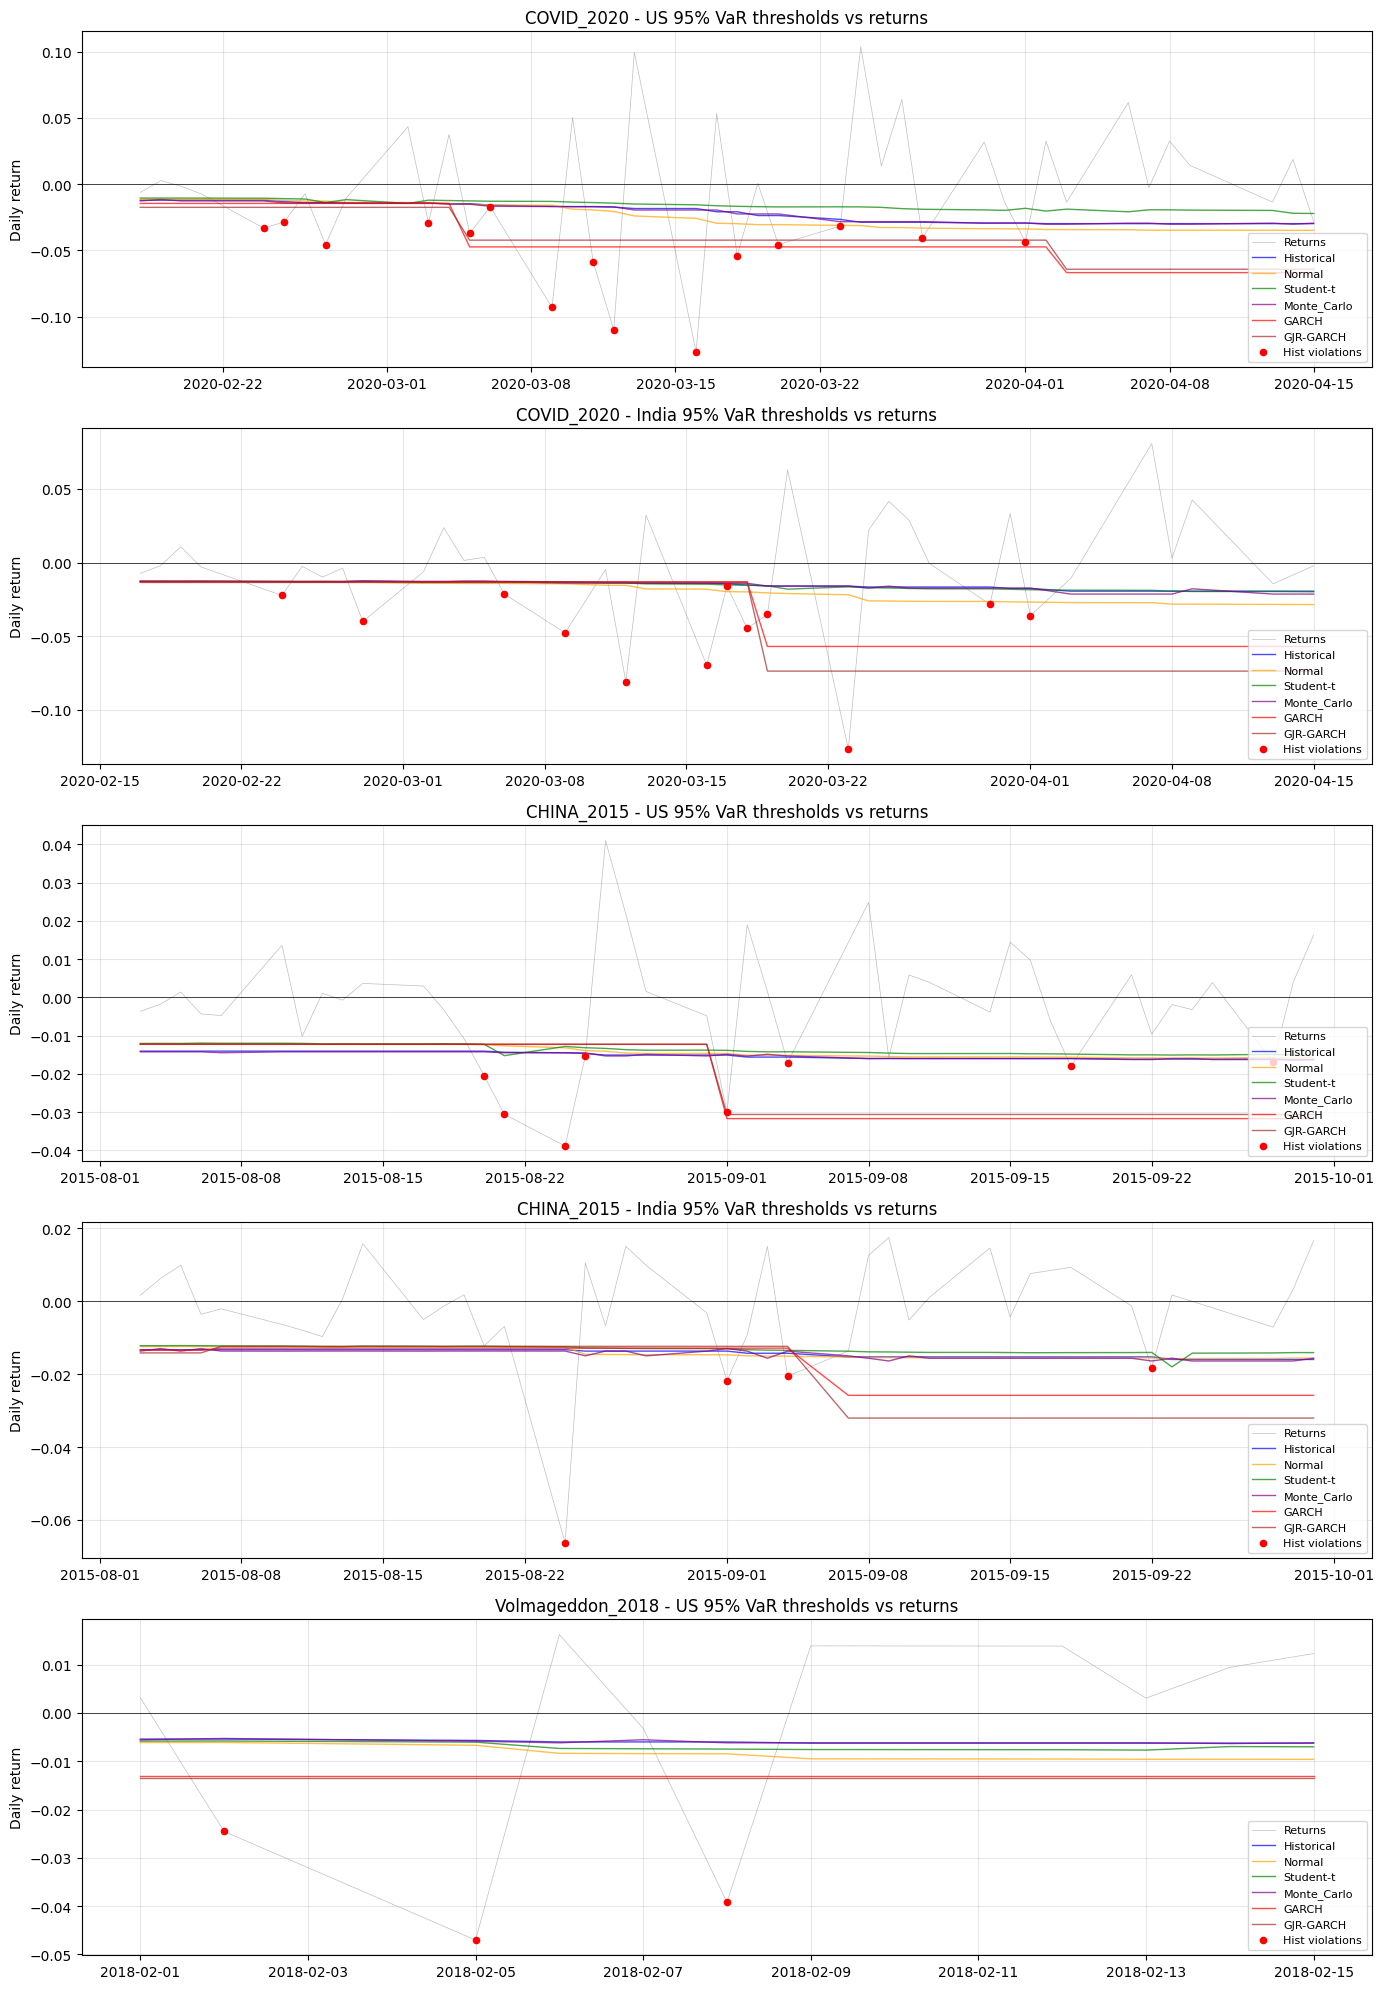

In [5]:
# build the list of plot panels: every (window, market) pair that's in scope
plot_cases = []
for window_name, (start, end, scope) in STRESS_WINDOWS.items():
    if scope == "US":
        markets = ["US"]
    else:
        markets = ["US", "India"]
    for market in markets:
        plot_cases.append((window_name, market, start, end))

fig, axes = plt.subplots(len(plot_cases), 1, figsize=(14, 4 * len(plot_cases)))
if len(plot_cases) == 1:
    axes = [axes]

colors = {
    "Historical": "blue",
    "Normal": "orange",
    "Student-t": "green",
    "Monte_Carlo": "purple",
    "GARCH": "red",
    "GJR-GARCH": "brown",
}

for ax, (window_name, market, start, end) in zip(axes, plot_cases):
    ret = returns_data[market]
    ret_window = ret.loc[pd.to_datetime(start):pd.to_datetime(end)]
    
    ax.plot(ret_window.index, ret_window, color="gray", linewidth=0.5, alpha=0.5, label="Returns")
    
    # Overlay each method's 95% VaR threshold 
    for method, var_series in var_data[market]["95%"].items():
        var_window = var_series.loc[pd.to_datetime(start):pd.to_datetime(end)]
        ax.plot(var_window.index, -var_window, color=colors[method], linewidth=1, alpha=0.7, label=method)
    
    #Highlight Historical method violation days as red dots
    hist_var = var_data[market]["95%"]["Historical"]
    aligned = pd.concat([ret_window, hist_var.loc[pd.to_datetime(start):pd.to_datetime(end)]], axis=1).dropna()
    aligned.columns = ["ret", "var"]
    violations = aligned["ret"] < -aligned["var"]       # boolean: True where realized resturn is worse than -VaR
    if violations.any():
        viol_dates = aligned[violations].index
        ax.scatter(viol_dates, aligned.loc[viol_dates, "ret"], color="red", s=20, zorder=5, label="Hist violations")
    
    ax.set_title(f"{window_name} - {market} 95% VaR thresholds vs returns")
    ax.set_ylabel("Daily return")
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

**Findings:**

- On the COVID 2020 panels, the static method thresholds sit barely below zero at the start of the window and only widen late in the crisis, after most of the damage is done. 
- The GARCH lines widen out much earlier, capturing the rising volatility within days. The red Historical-violation dots cluster heavily in late February and early March 2020, exactly when the static thresholds were lagging hardest.
- On the China 2015 panel, the picture is similar but the magnitude is smaller. GARCH again widens earlier than the static methods.
- On the Volmageddon 2018 panel, the chart shows a single huge red dot in early February with no warning in the surrounding days. None of the methods has a threshold deep enough to contain that day, because there was no preceding volatility for any model to respond to.

**This cell computes a forward-looking "what if" scenario on a hypotehical -10% shock.**

**For each method's most recent VaR forecast, I compute the breach ratio = |−10%| / VaR.**

**- A ratio of 1.0 means the shock exactly matches what the method warned about**

**- A ratio of 5.0 means the shock would be 5× deeper than predicted.**

In [6]:
shock_results = []
for market in ["US", "India"]:
    for level in ["95%", "99%"]:
        for method, var_series in var_data[market][level].items():
            most_recent_var = var_series.iloc[-1]           # the model's prediction for tomorrow
            breach_ratio = abs(HYPOTHETICAL_SHOCK) / most_recent_var        # |shock| / VaR. Breach ratio > 1 means shock gets through threshold
            shock_results.append({
                "market": market,
                "level": level,
                "method": method,
                "var_today": most_recent_var,
                "breach_ratio": breach_ratio,
            })

shock_df = pd.DataFrame(shock_results)
shock_pivot = shock_df.pivot_table(
    index=["market", "level"],
    columns="method",
    values="breach_ratio",
)

print(f"Hypothetical shock: {HYPOTHETICAL_SHOCK * 100:.1f}% return")
print()
print("Breach ratio (actual loss / VaR):")
print(shock_pivot.round(2))

Hypothetical shock: -10.0% return

Breach ratio (actual loss / VaR):
method        GARCH  GJR-GARCH  Historical  Monte_Carlo  Normal  Student-t
market level                                                              
India  95%    10.24       9.84        9.32         9.49    8.37       7.30
       99%     7.24       6.96        5.27         5.81    5.87       3.32
US     95%     9.32       9.79        7.62         7.47    6.46       8.57
       99%     6.59       6.92        3.60         3.13    4.50       4.30


**Findings:**

- Every breach ratio is well above 1.0 meaning a −10% single-day return would blow through every method's most recent threshold on both markets. That is expected because the −10% is a genuinely extreme event that happens rapidly like the Volmageddon 2018 event.
- GARCH and GJR-GARCH show the highest breach ratios at both levels.
- Historical and Monte Carlo show the lowest ratios at 99% because their 252-day window includes data from earlier higher-volatility regimes, so even in calm periods their thresholds stay wider than GARCH's.
- At 99%, every ratio is smaller than its 95% counterpart on the same market and method as expected because deeper threshold absorbs more of the shock.
- GARCH's whole strength is that its threshold tracks the current volatility regime. In a calm regime, that means a tight threshold and a high breach ratio against any extreme hypothetical. On the other hand, in an elevated regime, the threshold has already widened by the time the next bad day arrives and the ratio is lower. Static methods would do the opposite as they are slow to widen during crises and slow to tighten during calms.

**This cell writes the stress results table to data/processed/stress_test_summary.parquet. Notebook 06 reads this file directly and renders it as one of the dashboard tables.**

In [7]:
stress_results.to_parquet(PROCESSED_DATA_DIR / "stress_test_summary.parquet", index=False)
print("Saved stress_test_summary.parquet")

Saved stress_test_summary.parquet
